In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import render
from src import postprocess as _postprocess

import types

import DriftCorrectionFunctions as DCF


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251103_113734.log


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [7]:
image_folder = "/media/jbeckwith/Ezra Seagat/20251026_MassiveCells/Ximea/250pMATTO655_750pMCy3B_20perc561_60mW638_1/"

In [8]:
localisation_files = H_F.file_search(image_folder, ".h5", "")

In [9]:
metadata_files = H_F.file_search(image_folder, "metadata", "")

In [10]:
localisation_files

['/media/jbeckwith/Ezra Seagat/20251026_MassiveCells/Ximea/250pMATTO655_750pMCy3B_20perc561_60mW638_1/Localisations.h5',
 '/media/jbeckwith/Ezra Seagat/20251026_MassiveCells/Ximea/250pMATTO655_750pMCy3B_20perc561_60mW638_1/Localisations_Undrifted.h5']

In [11]:
loc_data = pd.read_hdf(localisation_files[1])

In [12]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [13]:
loc_data = loc_data[loc_data["xc_err"] < 1]
loc_data = loc_data[loc_data["yc_err"] < 1]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 1]
loc_data = loc_data[loc_data["s_y_err"] < 1]

loc_data = loc_data[loc_data["A_B_err"] < 0.15]
loc_data = loc_data[loc_data["A_G_err"] < 0.15]
loc_data = loc_data[loc_data["A_R_err"] < 0.15]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.01]
loc_data = loc_data[loc_data["A_R"] > 0.01]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[loc_data["photons"] < 100000]
loc_data = loc_data[loc_data["photons"] > 100]


loc_data = loc_data[loc_data["chi_sqr"] < 2]
loc_data = loc_data.drop('is_fiducial', axis=1)

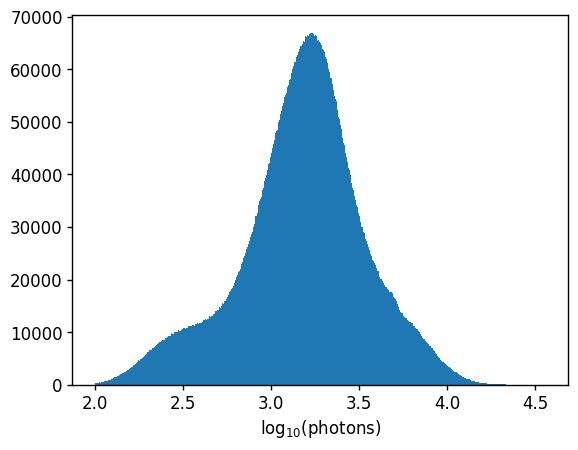

In [14]:
plt.hist(np.log10(loc_data['photons']), 1000);
#plt.hist(loc_data['A_G'], 1000, alpha=0.5);
plt.xlabel('log$_{10}$(photons)')
plt.show()

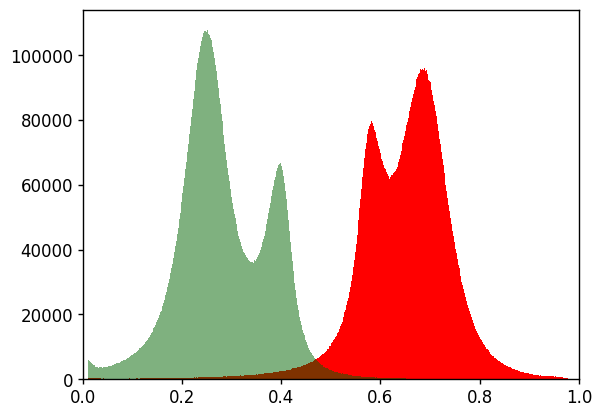

In [15]:
plt.hist(loc_data['A_R'], 1000, color='red');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

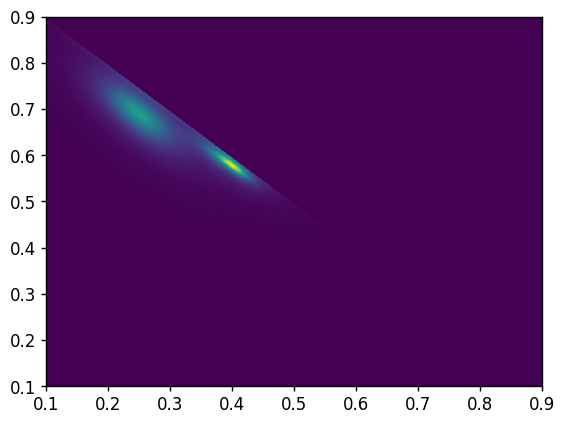

In [16]:
plt.hist2d(loc_data['A_G'], loc_data['A_R'], 1000);
plt.xlim([0.1, 0.9])
plt.ylim([0.1, 0.9])

# fit on two-D space
# initial guess in 1D space

plt.show()

In [ ]:
image = render.render(
    locs=loc_data.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

In [ ]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=50,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

In [ ]:
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [ ]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

example_image = render.render(
            locs=loc_data.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

In [ ]:
len(np.histogram_bin_edges(example_image.ravel(), 'sqrt'))

In [ ]:
drift_corrector = DCF.Drift_Correction_Functions()

region_centers, binary_mask, threshold, metadata = drift_corrector.detect_high_density_regions_from_image(
      smoothed_image=example_image,
      histogram_bins=821,
      threshold_percentile=99.5,
      pixelsize=69.0,
      title="Fiducial Detection"
  )

In [ ]:
selected_puncta, selection_metadata = drift_corrector.select_puncta_from_regions(
        locs=loc_data.to_records(index=False),                             # Your localization data
        region_centres=region_centers,         # Output from Step 1
        binary_mask=binary_mask,               # Output from Step 1
        pixelsize=info[0]['Pixelsize'],
        selection_box_size_nm=500.0,         # Box size around each region center (adjust as needed)
        min_localisations_per_region=int(0.4*info[0]['Frames']),      # Minimum locs for valid fiducial (adjust as needed)
        title="Step 2: Puncta Selection",
        create_plot=True
    )

In [ ]:
validated_fiducials, clustering_metadata = drift_corrector.identify_real_fiducials_with_clustering(
            selected_puncta=selected_puncta,
            min_samples_factor=0.5,    # Fraction of total frames (adjust as needed)
            retention_percentage = 0.7,
            frame_count=int(info[0]['Frames']),
            title="Fiducial Gaussian Fitting Analysis",
            create_plot=False
        )

In [ ]:
final_corrected_locs, drift_info = drift_corrector.apply_validated_fiducial_drift_correction(loc_data.to_records(index=False),
                                                                                            validated_fiducials)

In [ ]:
drift_info['drift_x'].shape

In [ ]:
plt.plot(drift_info['drift_x'][0, :]*69)
plt.plot(drift_info['drift_y'][0, :]*69)
plt.show()

In [ ]:
final_corrected_locs = pd.DataFrame(final_corrected_locs)

In [ ]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

example_image = render.render(
            locs=final_corrected_locs.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

In [ ]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, example_image.T, cmap='hot', cbar='off')

plt.show()

In [ ]:
oversampling = 8
n_locs, image_DNA, image_DNA_spectral = render.render(
        locs=final_corrected_locs.to_records(index=False),
        oversampling=oversampling,
        info=info,
        blur_method="gaussian_colour",
        c_max = 1,
        c_min = 0.0,
        densitymin=0.05
    )

In [ ]:
just_PAINT = final_corrected_locs[final_corrected_locs['is_fiducial'] == 0]

In [ ]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]


n_locs, image_DNA, image_DNA_spectral = render.render(
        locs=loc_data.to_records(index=False),
        oversampling=oversampling,
        info=info,
        blur_method="gaussian_colour",
        c_max = 0.9,
        c_min = 0.5,
        densitymin=0.075
    )

In [ ]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, image_DNA_spectral, cbar='off')

plt.show()

In [ ]:
X = np.vstack([just_PAINT['xc'], just_PAINT['yc']]).T
loc_precision = 0.75*(np.mean(just_PAINT['xc_err']) + np.mean(just_PAINT['yc_err']))
hdb = DBSCAN(eps=loc_precision, min_samples=40)
hdb.fit(X)

In [ ]:
len(np.unique(hdb.labels_))

In [ ]:
test = just_PAINT[hdb.labels_ > -1]

In [ ]:
oversampling = 1
n_locs, image_DNA, image_DNA_spectral = render.render(
        locs=test.to_records(index=False),
        oversampling=oversampling,
        info=info,
        blur_method="gaussian_colour",
        c_max = 0.9,
        c_min = 0.5,
        densitymin=0.05
    )

In [ ]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, image_DNA_spectral, cbar='off')

plt.show()

In [ ]:
IO._write_h5_database(df=just_PAINT, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted.h5', normalise_photons=False,
                      append=False)

In [17]:
# ============================================================================
# Channel Unmixing Test
# ============================================================================

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

Channel Unmixing
Input: 18741003 localizations
Channels: 2
Features: ['A_R', 'A_G']

Feature matrix: (18741003, 2)
Feature ranges:
  A_R: [0.010, 0.985], mean=0.649
  A_G: [0.010, 0.984], mean=0.284

Finding initial channel means (method: histogram_peaks)...
Initial means:
  Channel 0: A_R=0.585, A_G=0.390
  Channel 1: A_R=0.682, A_G=0.253

Estimating initial covariances from core regions (conservative)...
  Channel 0: det(cov)=0.000000, σ1=0.005, σ2=0.018
  Channel 1: det(cov)=0.000000, σ1=0.013, σ2=0.020



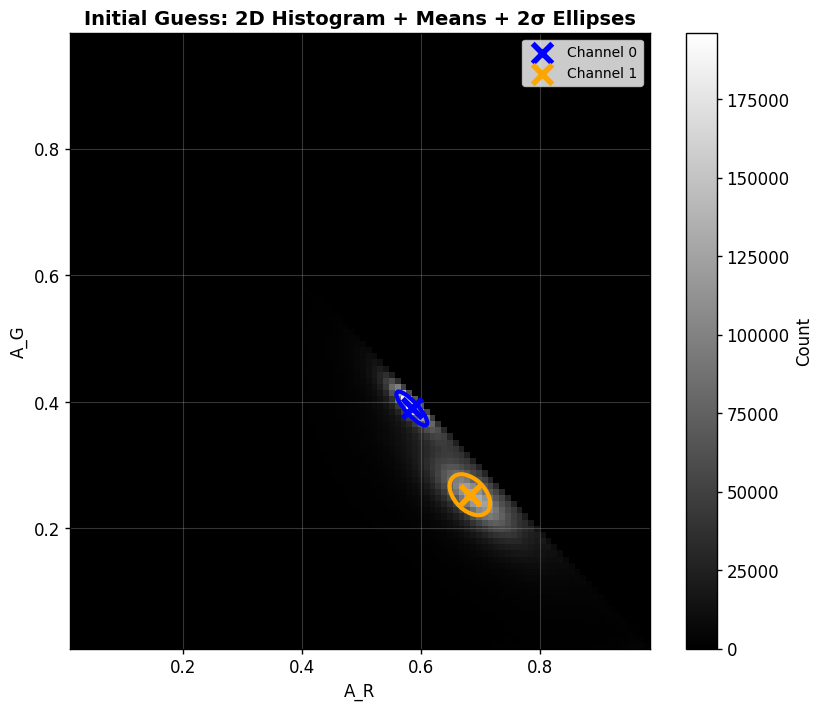

Fitting GMM (method: fixed, covariance: full)...
  Error columns available (mean errors: [ 0.00306312  0.00259876])
Using fixed initial guess (no EM refinement)
GMM fitting: converged
Fitted means:
  Channel 0: A_R=0.585, A_G=0.390 (weight: 35.0%)
  Channel 1: A_R=0.682, A_G=0.253 (weight: 65.0%)

Calculating posterior probabilities and assignments...
Calculating analytical FPR to determine confidence threshold (target: 0.050)...
Analytical accuracy: 1.000
Confusion matrix:
[[ 1.  0.]
 [ 0.  1.]]

Setting confidence threshold to 0.975 (from FPR=0.050)
Applying Mahalanobis distance outlier rejection...
  Outliers detected: 7171319 (38.27%, threshold=3.72)

Unmixing Complete
Assignments:
  Channel 0: 3,508,885 (18.7%)
  Channel 1: 7,701,823 (41.1%)
  Unassigned: 7,530,295 (40.2%)



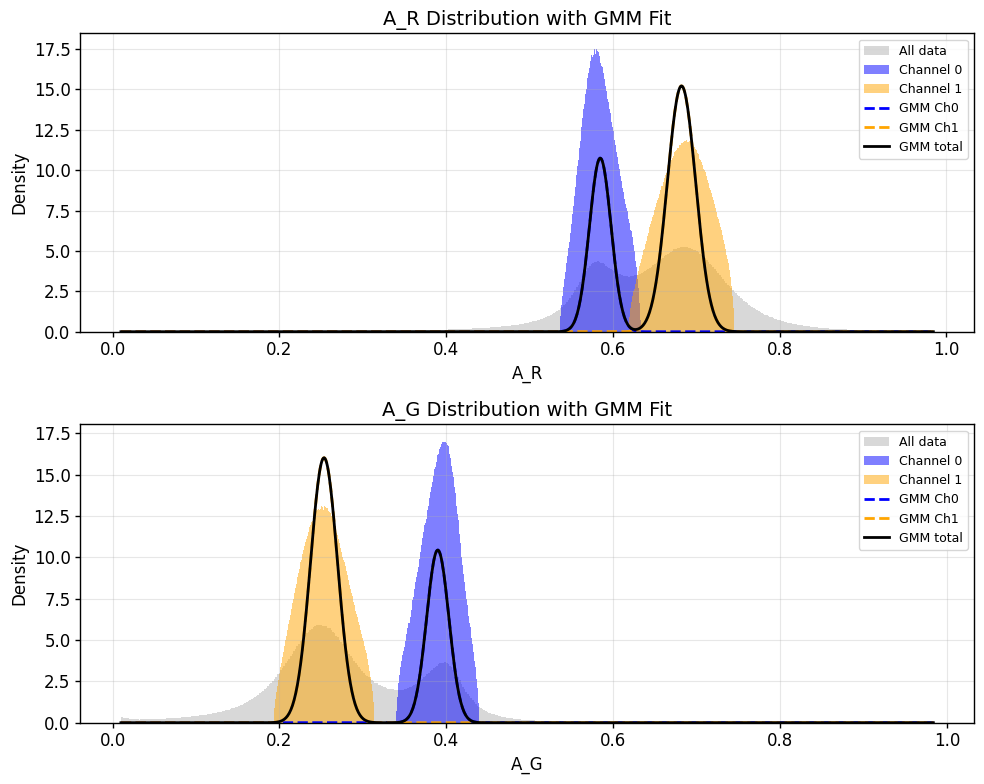

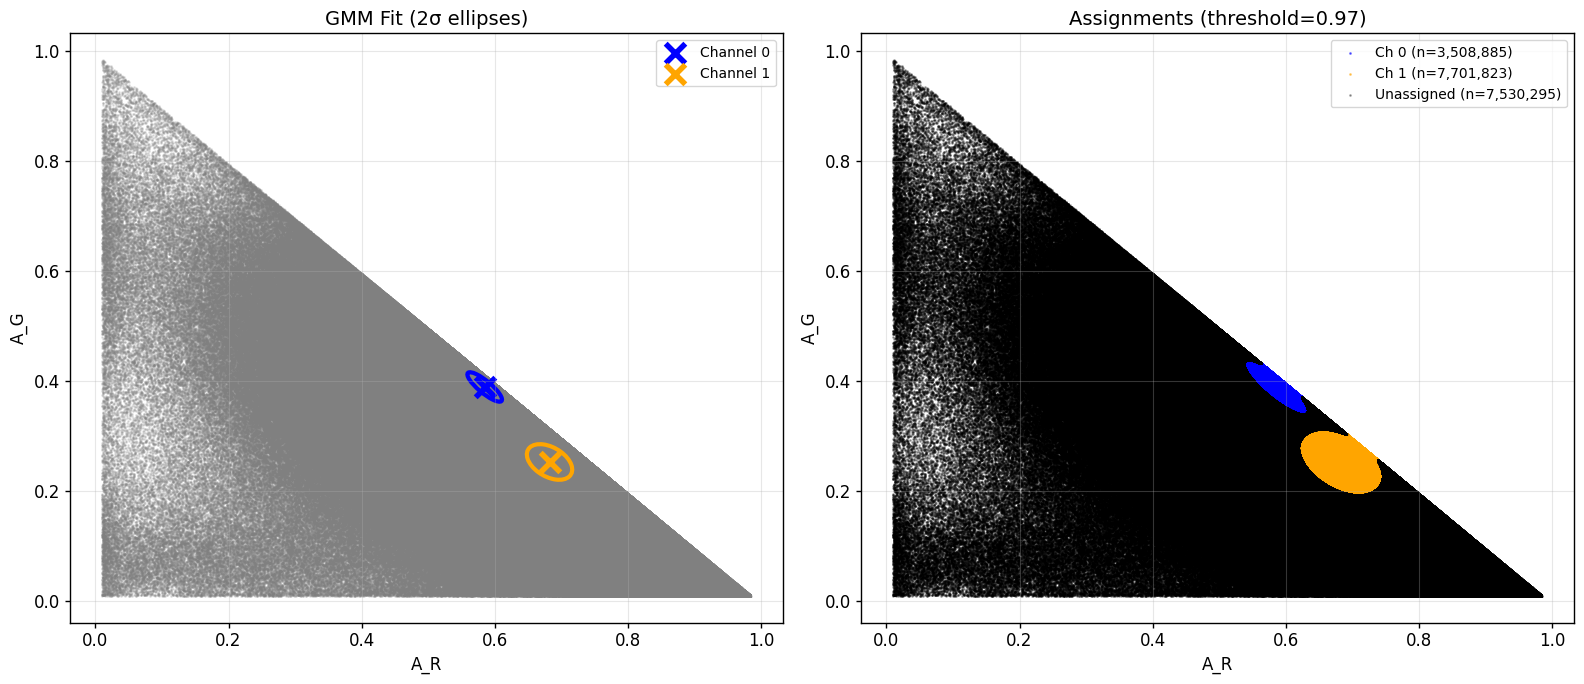

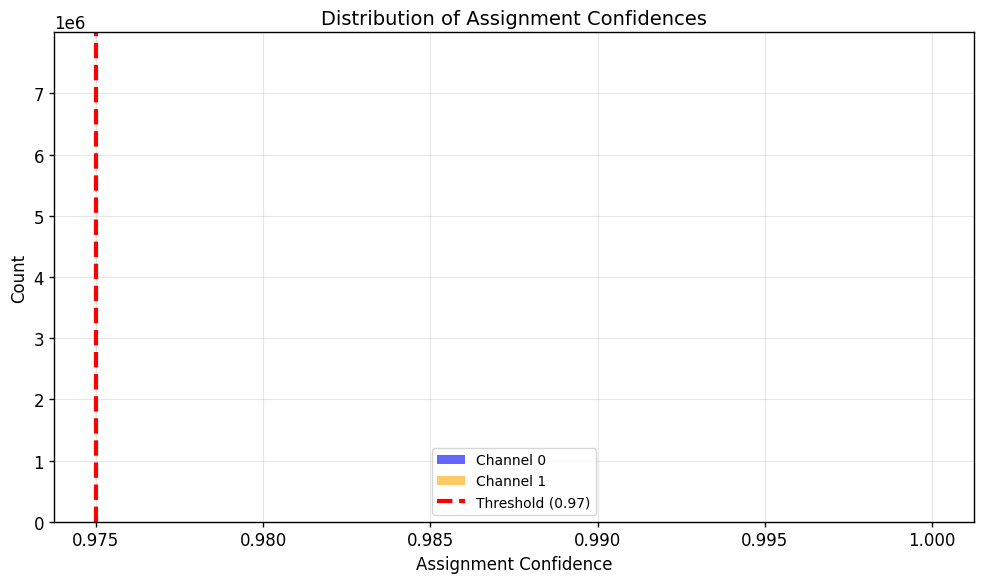

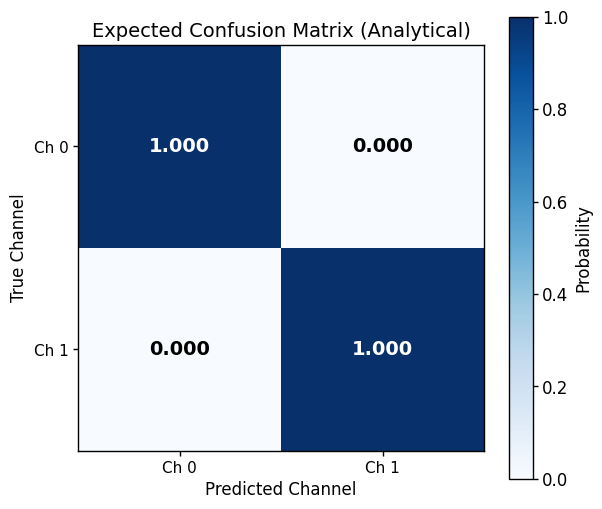

In [18]:
# Test channel unmixing on the filtered loc_data
# This data has ATTO655 (red) and Cy3B (green)

assigned_locs, metadata = SM_E.unmix_channels(
    loc_data,
    n_channels=2,
    channels_to_use=['A_R', 'A_G'],
    confidence_threshold=0.95,  # Start with 95% confidence
    false_positive_rate=0.05,
    initial_guess_method='histogram_peaks',
    gmm_fit_method='fixed',
    covariance_type='full',
    outlier_rejection='mahalanobis',
    mestimator_type='tukey',
    initial_guess_percentile=50,
    initial_guess_scale=0.5,
    verbose=True,
    plot_results=True
)

In [ ]:
# Print summary statistics
print("Channel Assignment Summary:")
print("="*60)
for k in range(2):
    n_k = metadata['n_assigned'][k]
    pct_k = 100 * n_k / len(loc_data)
    mean_conf_k = assigned_locs[assigned_locs['channel'] == k]['channel_confidence'].mean()
    print(f"Channel {k}: {n_k:,} locs ({pct_k:.1f}%), mean confidence: {mean_conf_k:.3f}")
    
    # Print mean RGB values for this channel
    ch_data = assigned_locs[assigned_locs['channel'] == k]
    print(f"  Mean A_R: {ch_data['A_R'].mean():.3f}")
    print(f"  Mean A_G: {ch_data['A_G'].mean():.3f}")
    print(f"  Mean A_B: {ch_data['A_B'].mean():.3f}")
    print()

pct_unassigned = 100 * metadata['n_unassigned'] / len(loc_data)
print(f"Unassigned: {metadata['n_unassigned']:,} ({pct_unassigned:.1f}%)")

In [ ]:
# Create additional histograms showing the separation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_ch = ['red', 'green']

# A_R histograms
ax = axes[0, 0]
for k in range(2):
    ch_data = assigned_locs[assigned_locs['channel'] == k]
    ax.hist(ch_data['A_R'], bins=200, alpha=0.6, color=colors_ch[k], 
            label=f'Channel {k} (n={len(ch_data):,})')
ax.set_xlabel('A_R', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('A_R Distribution by Channel', fontsize=14, weight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# A_G histograms  
ax = axes[0, 1]
for k in range(2):
    ch_data = assigned_locs[assigned_locs['channel'] == k]
    ax.hist(ch_data['A_G'], bins=200, alpha=0.6, color=colors_ch[k],
            label=f'Channel {k} (n={len(ch_data):,})')
ax.set_xlabel('A_G', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('A_G Distribution by Channel', fontsize=14, weight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# A_B histograms
ax = axes[1, 0]
for k in range(2):
    ch_data = assigned_locs[assigned_locs['channel'] == k]
    ax.hist(ch_data['A_B'], bins=200, alpha=0.6, color=colors_ch[k],
            label=f'Channel {k} (n={len(ch_data):,})')
ax.set_xlabel('A_B', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('A_B Distribution by Channel', fontsize=14, weight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Photons distribution
ax = axes[1, 1]
for k in range(2):
    ch_data = assigned_locs[assigned_locs['channel'] == k]
    ax.hist(np.log10(ch_data['photons']), bins=100, alpha=0.6, color=colors_ch[k],
            label=f'Channel {k} (n={len(ch_data):,})')
ax.set_xlabel('log10(photons)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Photon Distribution by Channel', fontsize=14, weight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
oversampling = 8

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image_0 = render.render(
            locs=assigned_locs[assigned_locs['channel'] == 0].to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

In [ ]:
image_1 = render.render(
            locs=assigned_locs[assigned_locs['channel'] == 1].to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image_0, cmap='hot', cbar='off')

plt.show()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image_1, cmap='hot', cbar='off')

plt.show()

In [20]:
channel_0 = assigned_locs[assigned_locs['channel'] == 0]

X = np.vstack([channel_0['xc'], channel_0['yc']]).T
loc_precision = 0.75*(np.mean(channel_0['xc_err']) + np.mean(channel_0['yc_err']))
hdb = DBSCAN(eps=loc_precision, min_samples=3)
hdb.fit(X)

DBSCAN(eps=0.18130970746278763, min_samples=3)

In [21]:
channel_0_pruned = channel_0[hdb.labels_ > -1]
channel_0_pruned['label'] = hdb.labels_[hdb.labels_ > -1]

/tmp/ipykernel_2355387/483749982.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  channel_0_pruned['label'] = hdb.labels_[hdb.labels_ > -1]


In [ ]:

image_0 = render.render(
            locs=channel_0_pruned.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image_0, cmap='hot', cbar='off')

plt.show()

In [22]:
channel_1 = assigned_locs[assigned_locs['channel'] == 1]

X = np.vstack([channel_1['xc'], channel_1['yc']]).T
loc_precision = 3*(np.mean(channel_1['xc_err']) + np.mean(channel_1['yc_err']))
hdb = DBSCAN(min_samples=10)
hdb.fit(X)

DBSCAN(min_samples=10)

In [23]:
channel_1_pruned = channel_1[hdb.labels_ > -1]
channel_1_pruned['label'] = hdb.labels_[hdb.labels_ > -1]

/tmp/ipykernel_2355387/2822060287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  channel_1_pruned['label'] = hdb.labels_[hdb.labels_ > -1]


In [ ]:

image_1 = render.render(
            locs=channel_1_pruned.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

fig, axs = plotter.create_figure()

axs = plotter.create_image_plot(axs, image_1, cmap='hot')
plt.show()

In [24]:
oversampling = 8
pixel_size = 69

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": pixel_size,        # pixel size always in nm
}]

# Render two channels
_, img1 = render.render(channel_0_pruned.to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')
_, img2 = render.render(channel_1_pruned.to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')


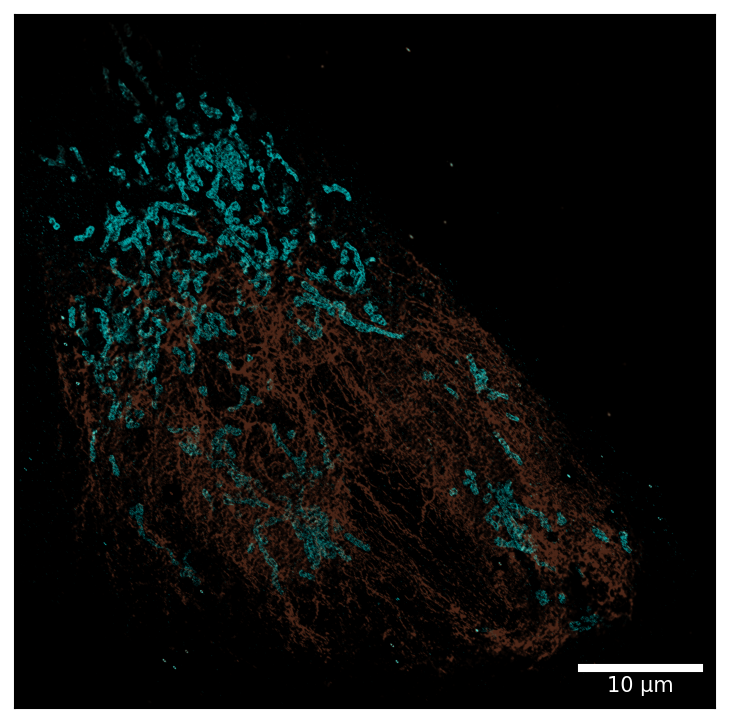

In [25]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

plotter.multichannel_overlay_plot(
  ax, [img2, img1],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='10 μm'
)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20251104_Geneva/fig/multicolour_camera/Massive_Cells_PAINT/'
plt.savefig(os.path.join(folder, 'Massive_Cells_Render.svg'), dpi=600, format='svg')
plt.show()

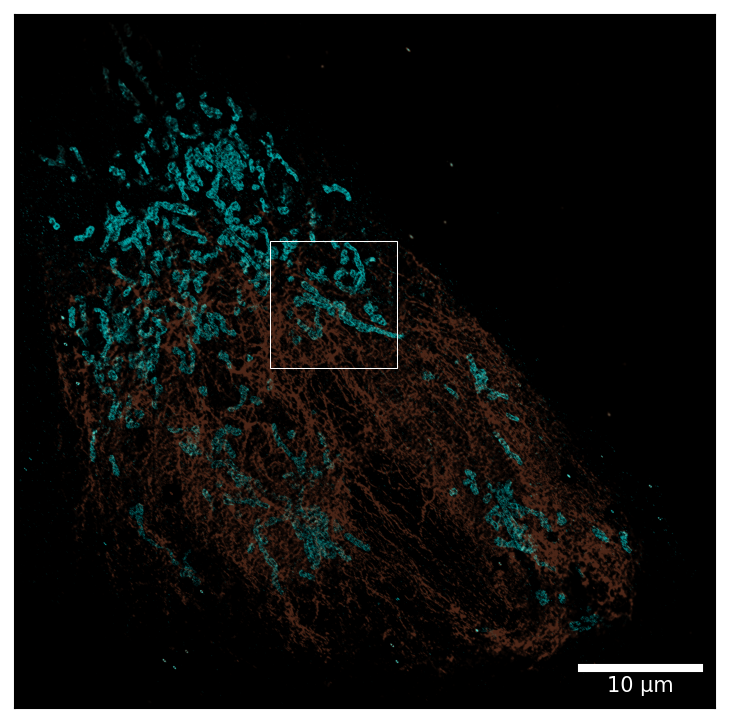

In [26]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

plotter.multichannel_overlay_plot(
  ax, [img2, img1],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='10 μm'
)
import matplotlib.patches as patches

rect = patches.Rectangle(
    (300 * oversampling, 400 * oversampling),
    150 * oversampling,
    150 * oversampling,
    linewidth=0.5,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
ax.add_patch(rect)


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20251104_Geneva/fig/multicolour_camera/Massive_Cells_PAINT/'
plt.savefig(os.path.join(folder, 'Massive_Cells_Render_Box.svg'), dpi=600, format='svg')
plt.show()

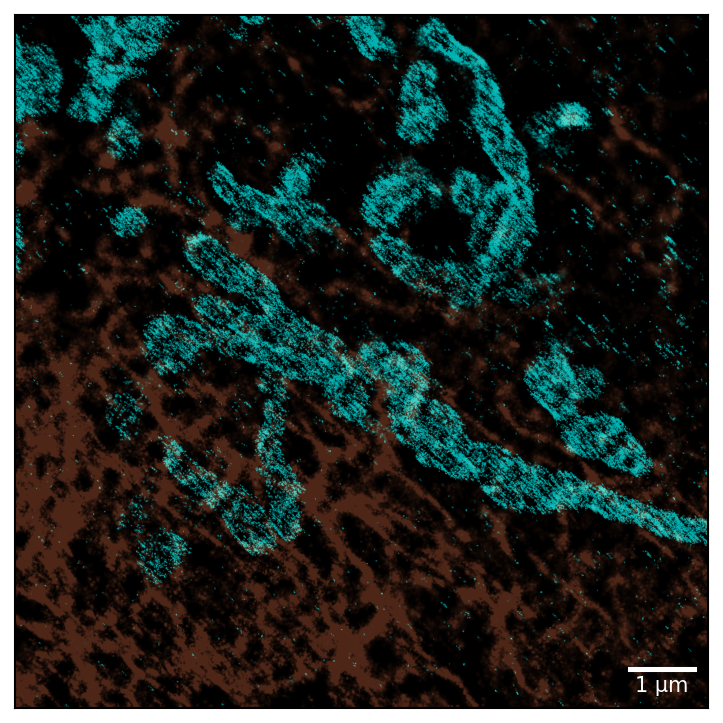

In [27]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

img1_subset = img1[int(400 * oversampling):int((400+150) * oversampling), int(300 * oversampling):int((300+150) * oversampling)]
img2_subset = img2[int(400 * oversampling):int((400+150) * oversampling), int(300 * oversampling):int((300+150) * oversampling)]


plotter.multichannel_overlay_plot(
  ax, [img2_subset, img1_subset],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=1000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='1 μm'
)


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20251104_Geneva/fig/multicolour_camera/Massive_Cells_PAINT/'
plt.savefig(os.path.join(folder, 'Massive_Cells_Render_Zoomin.svg'), dpi=600, format='svg')
plt.show()